In [149]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [150]:
df = pd.read_csv("Data/tech_job_market_2019_2026.csv")

In [151]:
df.shape

(115000, 28)

### There are 115000 rows and 28 cols

In [152]:
df.head()

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
0,JOB041385,CobaltWealth,MNC,HealthTech,146085,Germany,SOC Analyst,Mid,3,5,...,2023-11-12 00:00:00,2023-11-20,Filled,98.0,4.0,5.0,5.0,-1,-1,N
1,JOB018462,DriftLearn,Mid-size,Cloud/Infra,5882,USA,Mobile Engineer (iOS),Mid,1,4,...,2025-06-29 00:00:00,NaN,Open,134.0,2.0,1.0,0.0,NaN,NaN,No
2,JOB110011,AnchorBuzz Labs,MNC,HealthTech,186507,USA,QA Engineer,Lead,7,15,...,2026-01-24 00:00:00,2026-02-08,Filled,36.0,4.0,1.0,1.0,238800.0,274700.0,0
3,JOB073462,KiteSphere,Unicorn,HealthTech,10930,Brazil,Research Scientist,Entry,1,4,...,2020-12-09 00:00:00,2020-12-21,Filled,300.0,1.0,6.0,5.0,96300.0,104000.0,Yes
4,JOB051683,AetherNode Co,MNC,Social/AdTech,42510,USA,Product Manager,Senior,6,9,...,2025-07-19 00:00:00,2025-09-15,Filled,43.0,3.0,1.0,1.0,"$186,800",245400.0,1


In [153]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 115000 entries, 0 to 114999
Data columns (total 28 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   job_id                        115000 non-null  str    
 1   company_name                  115000 non-null  str    
 2   company_type                  115000 non-null  str    
 3   sector                        115000 non-null  str    
 4   company_size_employees        115000 non-null  int64  
 5   hq_country                    115000 non-null  str    
 6   job_role                      115000 non-null  str    
 7   seniority_level               115000 non-null  str    
 8   years_experience_min          115000 non-null  int64  
 9   years_experience_max          115000 non-null  int64  
 10  required_tech_stack           115000 non-null  str    
 11  primary_programming_language  92525 non-null   str    
 12  work_mode                     115000 non-null  str    


### There are 21 object type cols, 3 integer type cols, 4 float type cols

In [154]:
df.columns

Index(['job_id', 'company_name', 'company_type', 'sector',
       'company_size_employees', 'hq_country', 'job_role', 'seniority_level',
       'years_experience_min', 'years_experience_max', 'required_tech_stack',
       'primary_programming_language', 'work_mode', 'visa_sponsorship_offered',
       'job_location_country', 'job_location_city', 'salary_currency',
       'posting_date', 'application_deadline', 'date_position_filled',
       'position_status', 'number_of_applicants', 'number_of_interview_rounds',
       'offers_extended', 'offers_accepted', 'salary_min_usd',
       'salary_max_usd', 'layoff_within_12_months_flag'],
      dtype='str')

In [155]:
print(df.columns.tolist())

['job_id', 'company_name', 'company_type', 'sector', 'company_size_employees', 'hq_country', 'job_role', 'seniority_level', 'years_experience_min', 'years_experience_max', 'required_tech_stack', 'primary_programming_language', 'work_mode', 'visa_sponsorship_offered', 'job_location_country', 'job_location_city', 'salary_currency', 'posting_date', 'application_deadline', 'date_position_filled', 'position_status', 'number_of_applicants', 'number_of_interview_rounds', 'offers_extended', 'offers_accepted', 'salary_min_usd', 'salary_max_usd', 'layoff_within_12_months_flag']


In [156]:
df.describe()

,company_size_employees,years_experience_min,years_experience_max,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted
count,115000.000000,115000.000000,115000.000000,113890.000000,114564.000000,114670.000000,114670.000000
mean,105386.103122,3.004452,6.665443,181.659215,3.307653,1.349786,1.196634
std,102117.290040,3.093383,5.073654,436.344753,1.418283,1.457267,1.122837
min,10.000000,0.000000,0.000000,-5.000000,1.000000,0.000000,0.000000
25%,6038.750000,1.000000,3.000000,62.000000,2.000000,1.000000,1.000000
50%,88364.000000,2.000000,6.000000,119.000000,3.000000,1.000000,1.000000
75%,169840.250000,5.000000,9.000000,213.000000,4.000000,1.000000,1.000000
max,488674.000000,24.000000,24.000000,36816.000000,8.000000,8.000000,10.000000


In [157]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
company_size_employees,115000.0,105386.103122,102117.290040,10.0,6038.75,88364.0,169840.25,488674.0
years_experience_min,115000.0,3.004452,3.093383,0.0,1.00,2.0,5.00,24.0
years_experience_max,115000.0,6.665443,5.073654,0.0,3.00,6.0,9.00,24.0
number_of_applicants,113890.0,181.659215,436.344753,-5.0,62.00,119.0,213.00,36816.0
number_of_interview_rounds,114564.0,3.307653,1.418283,1.0,2.00,3.0,4.00,8.0
offers_extended,114670.0,1.349786,1.457267,0.0,1.00,1.0,1.00,8.0
offers_accepted,114670.0,1.196634,1.122837,0.0,1.00,1.0,1.00,10.0


In [158]:
df.isnull().sum()

job_id                              0
company_name                        0
company_type                        0
sector                              0
company_size_employees              0
hq_country                          0
job_role                            0
seniority_level                     0
years_experience_min                0
years_experience_max                0
required_tech_stack                 0
primary_programming_language    22475
work_mode                           0
visa_sponsorship_offered            0
job_location_country                0
job_location_city               25107
salary_currency                     0
posting_date                        0
application_deadline             5757
date_position_filled            25781
position_status                     0
number_of_applicants             1110
number_of_interview_rounds        436
offers_extended                   330
offers_accepted                   330
salary_min_usd                   3318
salary_max_u

In [159]:
df.isnull().sum().sort_values(ascending=False).head(15)

date_position_filled            25781
job_location_city               25107
primary_programming_language    22475
application_deadline             5757
salary_max_usd                   3318
salary_min_usd                   3318
number_of_applicants             1110
number_of_interview_rounds        436
offers_accepted                   330
offers_extended                   330
company_type                        0
job_id                              0
required_tech_stack                 0
years_experience_max                0
years_experience_min                0
dtype: int64

### The highest missing values are found in date_position_filled,job_location_city,primary_programming_language

In [160]:
df.duplicated().sum()

np.int64(1193)

### There are 1193 duplicate rows. We have to remove them.

In [161]:
df['job_id'].duplicated().sum()

np.int64(2000)

In [162]:
df.duplicated().sum()

np.int64(1193)

### Now there are 0 duplicate rows

In [163]:
df.describe()

,company_size_employees,years_experience_min,years_experience_max,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted
count,115000.000000,115000.000000,115000.000000,113890.000000,114564.000000,114670.000000,114670.000000
mean,105386.103122,3.004452,6.665443,181.659215,3.307653,1.349786,1.196634
std,102117.290040,3.093383,5.073654,436.344753,1.418283,1.457267,1.122837
min,10.000000,0.000000,0.000000,-5.000000,1.000000,0.000000,0.000000
25%,6038.750000,1.000000,3.000000,62.000000,2.000000,1.000000,1.000000
50%,88364.000000,2.000000,6.000000,119.000000,3.000000,1.000000,1.000000
75%,169840.250000,5.000000,9.000000,213.000000,4.000000,1.000000,1.000000
max,488674.000000,24.000000,24.000000,36816.000000,8.000000,8.000000,10.000000


In [164]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
company_size_employees,115000.0,105386.103122,102117.290040,10.0,6038.75,88364.0,169840.25,488674.0
years_experience_min,115000.0,3.004452,3.093383,0.0,1.00,2.0,5.00,24.0
years_experience_max,115000.0,6.665443,5.073654,0.0,3.00,6.0,9.00,24.0
number_of_applicants,113890.0,181.659215,436.344753,-5.0,62.00,119.0,213.00,36816.0
number_of_interview_rounds,114564.0,3.307653,1.418283,1.0,2.00,3.0,4.00,8.0
offers_extended,114670.0,1.349786,1.457267,0.0,1.00,1.0,1.00,8.0
offers_accepted,114670.0,1.196634,1.122837,0.0,1.00,1.0,1.00,10.0


### the value of mean > median so thereis positive skewness .

In [165]:
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)

Index(['job_id', 'company_name', 'company_type', 'sector', 'hq_country',
       'job_role', 'seniority_level', 'required_tech_stack',
       'primary_programming_language', 'work_mode', 'visa_sponsorship_offered',
       'job_location_country', 'job_location_city', 'salary_currency',
       'posting_date', 'application_deadline', 'date_position_filled',
       'position_status', 'salary_min_usd', 'salary_max_usd',
       'layoff_within_12_months_flag'],
      dtype='str')


C:\Users\vartika singh\AppData\Local\Temp\ipykernel_9460\4182786301.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


### Categorical Consistency

In [166]:
df['company_type'].value_counts(dropna=False)

company_type
MNC           56053
Mid-size      20305
Unicorn       16078
FAANG-tier    15963
Startup        6601
Name: count, dtype: int64

#### The company_type column contains five distinct categories: MNC, Mid-size, Unicorn, FAANG-tier, and Startup. No missing values or obvious spelling and casing inconsistencies were observed.

In [167]:
df['sector'].value_counts(dropna=False)

sector
E-commerce       16680
HealthTech       15273
Fintech          13134
EdTech           11523
Social/AdTech     9022
AI/ML             8900
SaaS              8620
Crypto/Web3       8038
Cloud/Infra       6567
Cybersecurity     5739
Logistics         5289
Gaming            5045
e-commerce         175
healthtech         147
fintech            141
edtech             126
social/adtech      100
crypto/web3         89
ai/ml               88
saas                88
cloud/infra         60
gaming              57
cybersecurity       50
logistics           49
Name: count, dtype: int64

### casing inconsistencies were observed.

In [168]:
df['sector']=df['sector'].str.strip().str.lower()

In [169]:
df['sector'].value_counts(dropna=False)

sector
e-commerce       16855
healthtech       15420
fintech          13275
edtech           11649
social/adtech     9122
ai/ml             8988
saas              8708
crypto/web3       8127
cloud/infra       6627
cybersecurity     5789
logistics         5338
gaming            5102
Name: count, dtype: int64

In [170]:
df['hq_country'].value_counts(dropna=False)

hq_country
USA            35732
India          18966
UK             15558
Germany         7190
Canada          6251
Brazil          5950
Singapore       5833
France          5101
Australia       3459
UAE             3189
Israel          3038
Netherlands     2636
Ireland         2097
Name: count, dtype: int64

In [171]:
df['job_role'].value_counts(dropna=False)

job_role
Backend Engineer             6011
Embedded Systems Engineer    5987
QA Engineer                  5910
Software Engineer            5881
Frontend Engineer            5851
                             ... 
 QA Engineer                    1
 FRONTEND ENGINEER              1
 Data Analyst                   1
 Mobile Engineer (iOS)          1
 DATA ENGINEER                  1
Name: count, Length: 160, dtype: int64

### inconsistencies are observed

In [172]:
df['job_role']=df['job_role'].str.strip().str.lower()

In [173]:
df['job_role'].value_counts(dropna=False)

job_role
backend engineer                 6169
embedded systems engineer        6144
qa engineer                      6062
software engineer                6023
frontend engineer                6016
mobile engineer (ios)            5962
mobile engineer (android)        5909
full stack engineer              5905
devops engineer                  3702
infrastructure engineer          3690
cloud engineer                   3648
platform engineer                3637
site reliability engineer        3627
machine learning engineer        3200
data analyst                     3181
analytics engineer               3023
data scientist                   3016
research scientist               2987
data engineer                    2981
product owner                    2946
product manager                  2936
technical program manager        2901
associate product manager        2898
soc analyst                      2348
penetration tester               2335
security engineer                2334
app

In [174]:
df['seniority_level'].value_counts(dropna=False)

seniority_level
Mid          39094
Entry        28621
Senior       23000
Lead         10482
Intern        9251
Principal     4552
Name: count, dtype: int64

In [175]:
df['required_tech_stack'].value_counts(dropna=False).head(20)

required_tech_stack
Sketch, Framer        279
Adobe XD, Framer      254
Figma, Framer         254
Adobe XD, Figma       250
Figma, Adobe XD       249
Sketch, Adobe XD      243
Framer, Sketch        242
Framer, Figma         237
Sketch, Figma         229
Figma, Sketch         228
Adobe XD, Sketch      226
Framer, Adobe XD      203
TypeScript, Swift     192
C++, React            191
C++, Go               190
C++, TypeScript       188
Swift, Python         185
C++, Python           184
TypeScript, Kotlin    183
React, Node.js        183
Name: count, dtype: int64

### here we will use feature engineering later to seperate out these columns and make a new coln

In [176]:
df['primary_programming_language'].value_counts(dropna=False)

primary_programming_language
NaN           22475
Python        19390
Go            14665
Bash           5975
Java           5921
JavaScript     5883
C++            5801
Kotlin         5798
Swift          5780
TypeScript     5774
Scala          4505
R              4474
SQL            4429
C              3037
Unknown         556
TBD             537
Name: count, dtype: int64

In [177]:
df['work_mode'].value_counts(dropna=False)

work_mode
Hybrid            48946
Remote            32320
Onsite            26731
HYBRID             1511
hybrid             1348
remote              598
Work From Home      567
WFH                 557
REMOTE              556
ONSITE              474
onsite              468
In-office           466
On-site             458
Name: count, dtype: int64

### short forms are  used which are causing inconsistencies 

In [178]:
df['work_mode'] = df['work_mode'].str.strip().str.lower()

df['work_mode'] = df['work_mode'].replace(
    {
    'wfh': 'remote',
    'work from home': 'remote',
    'on-site': 'onsite'
    })

In [179]:
df['work_mode'].value_counts(dropna=False)

work_mode
hybrid       51805
remote       34598
onsite       28131
in-office      466
Name: count, dtype: int64

In [180]:
df['visa_sponsorship_offered'].value_counts(dropna=False)

visa_sponsorship_offered
0        19831
N        19774
False    19746
No       19545
Yes       9104
True      9032
Y         8988
1         8980
Name: count, dtype: int64

### diff representations are used for yes/no

In [181]:
df['visa_sponsorship_offered'] = df['visa_sponsorship_offered'].replace(
    {
    '0': 'No',
    'False': 'No',
    'N': 'No',
    'No': 'No',
    'Yes': 'Yes',
    'True': 'Yes',
    '1': 'Yes',
    'Y': 'Yes'
})

In [182]:
df['visa_sponsorship_offered'].value_counts(dropna=False)

visa_sponsorship_offered
No     78896
Yes    36104
Name: count, dtype: int64

In [183]:
df['position_status'].value_counts(dropna=False)

position_status
Filled       91064
Open         10161
Cancelled     8048
Withdrawn     5727
Name: count, dtype: int64

In [184]:
df.columns

Index(['job_id', 'company_name', 'company_type', 'sector',
       'company_size_employees', 'hq_country', 'job_role', 'seniority_level',
       'years_experience_min', 'years_experience_max', 'required_tech_stack',
       'primary_programming_language', 'work_mode', 'visa_sponsorship_offered',
       'job_location_country', 'job_location_city', 'salary_currency',
       'posting_date', 'application_deadline', 'date_position_filled',
       'position_status', 'number_of_applicants', 'number_of_interview_rounds',
       'offers_extended', 'offers_accepted', 'salary_min_usd',
       'salary_max_usd', 'layoff_within_12_months_flag'],
      dtype='str')

In [185]:
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)

Index(['job_id', 'company_name', 'company_type', 'sector', 'hq_country',
       'job_role', 'seniority_level', 'required_tech_stack',
       'primary_programming_language', 'work_mode', 'visa_sponsorship_offered',
       'job_location_country', 'job_location_city', 'salary_currency',
       'posting_date', 'application_deadline', 'date_position_filled',
       'position_status', 'salary_min_usd', 'salary_max_usd',
       'layoff_within_12_months_flag'],
      dtype='str')


C:\Users\vartika singh\AppData\Local\Temp\ipykernel_9460\4182786301.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


In [186]:
df['salary_currency'].value_counts(dropna=False)

salary_currency
USD    36269
INR    19639
EUR    17076
GBP    14620
CAD     6319
SGD     5781
BRL     5360
AUD     3585
ILS     3292
AED     3059
Name: count, dtype: int64

In [187]:
df['posting_date'].value_counts(dropna=False)

posting_date
2026-02-06    98
2026-01-04    97
2026-02-16    96
2025-06-13    93
2024-02-15    92
              ..
2022-07-29     1
2024-03-31     1
2025-11-29     1
2025-06-30     1
2026-01-29     1
Name: count, Length: 2638, dtype: int64

In [188]:
df['application_deadline'].describe()

count                109243
unique                 2843
top       Open Until Filled
freq                   2827
Name: application_deadline, dtype: object

### The application_deadline coloumns contains 2843 unique  values,with "open until filled "being most frequent category.This means this col contains both deadline info and non date textual values. 

In [189]:
df['date_position_filled'].value_counts(dropna=False)

date_position_filled
NaN           25781
2026-09-03     1281
2025-11-18       72
2026-06-04       71
2026-03-31       71
              ...  
2019-01-14        1
2019-01-20        1
2019-01-03        1
2019-01-18        1
2019-01-05        1
Name: count, Length: 2792, dtype: int64

In [190]:
df['position_status'].value_counts(dropna=False)

position_status
Filled       91064
Open         10161
Cancelled     8048
Withdrawn     5727
Name: count, dtype: int64

In [191]:
df['layoff_within_12_months_flag'].value_counts(dropna=False)

layoff_within_12_months_flag
N        25170
False    24999
0        24976
No       24780
Y         3818
Yes       3801
1         3764
True      3692
Name: count, dtype: int64

### diff representation of yes/no is used causing inconsistencies

In [192]:
df['layoff_within_12_months_flag'] = df['layoff_within_12_months_flag'].replace(
    {
    'N': 'No',
    '0': 'No',
    'False': 'No',
    'Y': 'Yes',
    '1': 'Yes',
    'True': 'Yes'
})

In [193]:
df['layoff_within_12_months_flag'].value_counts(dropna=False)

layoff_within_12_months_flag
No     99925
Yes    15075
Name: count, dtype: int64

In [194]:
df['job_id'].value_counts(dropna=False)

job_id
JOB051125    3
JOB004262    3
JOB001361    3
JOB088269    3
JOB054307    3
            ..
JOB012896    1
JOB060961    1
JOB006013    1
JOB063108    1
JOB006559    1
Name: count, Length: 113000, dtype: int64

In [195]:
df['company_name'].value_counts(dropna=False)

company_name
NexusShield            3265
MeridianToken          3201
RidgeFreight Labs      3106
SpireCloud             3030
AetherAI Co            2746
                       ... 
AETHERCOGNITION           1
  MeridianReach Inc       1
NovaArcade Co             1
  SpireHub Inc            1
CATALYSTCONNECT CO        1
Name: count, Length: 898, dtype: int64

In [196]:
df['salary_min_usd'].describe()

count     111682
unique      4795
top           -1
freq         737
Name: salary_min_usd, dtype: object

### the salary_min_usd colomn contains 727 occurences of-1,which may represent invalid salary information. 

In [197]:
df['salary_max_usd'].value_counts().head(10)

salary_max_usd
-1               737
Not Disclosed    686
93400.0          105
107000.0         103
104900.0         102
118000.0         100
111500.0          96
98100.0           95
100100.0          95
112000.0          95
Name: count, dtype: int64

The salary_max_usd column contains both numerical salary values and non-numeric placeholders such as -1 and "Not Disclosed". These invalid or unavailable salary values need to be handled before converting the column to a numeric datatype and performing further analysis.

### Logical AND Referential checks

In [198]:
(df['salary_min_usd'] > df['salary_max_usd']).sum()

np.int64(16939)

The logical consistency check identified 16,772 records where the minimum salary is greater than max salary

In [199]:
df.columns

Index(['job_id', 'company_name', 'company_type', 'sector',
       'company_size_employees', 'hq_country', 'job_role', 'seniority_level',
       'years_experience_min', 'years_experience_max', 'required_tech_stack',
       'primary_programming_language', 'work_mode', 'visa_sponsorship_offered',
       'job_location_country', 'job_location_city', 'salary_currency',
       'posting_date', 'application_deadline', 'date_position_filled',
       'position_status', 'number_of_applicants', 'number_of_interview_rounds',
       'offers_extended', 'offers_accepted', 'salary_min_usd',
       'salary_max_usd', 'layoff_within_12_months_flag'],
      dtype='str')

In [200]:
(df['years_experience_min'] > df['years_experience_max']).sum()

np.int64(315)

The logical consistency check identified 315 records where the min year experience is greater than max year experience

In [201]:
(df['offers_accepted'] > df['offers_extended']).sum()

np.int64(597)

The logical consistency check identified 591 records where the offer accepted is greater than offer extended

In [202]:
(df['application_deadline'] < df['posting_date']).sum()

np.int64(0)

In [203]:
(df['date_position_filled'] < df['posting_date']).sum()

np.int64(445)

The logical consistency check identified 439 records where the posting date is given before date position filled 

In [204]:
(df['number_of_interview_rounds'] < 0).sum()

np.int64(0)

In [205]:
(df['number_of_applicants'] < 0).sum()

np.int64(247)

there are 243 negative number of applicants which generally cause problem in further analysis

In [206]:
((df['offers_extended'] < 0) | (df['offers_accepted'] < 0)).sum()

np.int64(0)

In [207]:
((df['years_experience_min'] < 0) | (df['years_experience_max'] < 0)).sum()

np.int64(0)

 Overall, the logical and referential checks revealed several logical inconsistencies in the dataset, including invalid salary ranges, experience ranges, offer counts, position-filled dates, and negative applicant values. However, application deadlines and interview rounds were found to be logically consistent. These issues should be considered before further analysis and interpretation.

### Numerical Distribution and outliers 

In [208]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(numerical_cols)

Index(['company_size_employees', 'years_experience_min',
       'years_experience_max', 'number_of_applicants',
       'number_of_interview_rounds', 'offers_extended', 'offers_accepted'],
      dtype='str')


In [209]:
df[numerical_cols].describe()

,company_size_employees,years_experience_min,years_experience_max,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted
count,115000.000000,115000.000000,115000.000000,113890.000000,114564.000000,114670.000000,114670.000000
mean,105386.103122,3.004452,6.665443,181.659215,3.307653,1.349786,1.196634
std,102117.290040,3.093383,5.073654,436.344753,1.418283,1.457267,1.122837
min,10.000000,0.000000,0.000000,-5.000000,1.000000,0.000000,0.000000
25%,6038.750000,1.000000,3.000000,62.000000,2.000000,1.000000,1.000000
50%,88364.000000,2.000000,6.000000,119.000000,3.000000,1.000000,1.000000
75%,169840.250000,5.000000,9.000000,213.000000,4.000000,1.000000,1.000000
max,488674.000000,24.000000,24.000000,36816.000000,8.000000,8.000000,10.000000


In [210]:
df[['salary_min_usd', 'salary_max_usd']].dtypes

salary_min_usd    str
salary_max_usd    str
dtype: object

In [211]:
df.head(10)

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
0,JOB041385,CobaltWealth,MNC,healthtech,146085,Germany,soc analyst,Mid,3,5,...,2023-11-12 00:00:00,2023-11-20,Filled,98.0,4.0,5.0,5.0,-1,-1,No
1,JOB018462,DriftLearn,Mid-size,cloud/infra,5882,USA,mobile engineer (ios),Mid,1,4,...,2025-06-29 00:00:00,NaN,Open,134.0,2.0,1.0,0.0,NaN,NaN,No
2,JOB110011,AnchorBuzz Labs,MNC,healthtech,186507,USA,qa engineer,Lead,7,15,...,2026-01-24 00:00:00,2026-02-08,Filled,36.0,4.0,1.0,1.0,238800.0,274700.0,No
3,JOB073462,KiteSphere,Unicorn,healthtech,10930,Brazil,research scientist,Entry,1,4,...,2020-12-09 00:00:00,2020-12-21,Filled,300.0,1.0,6.0,5.0,96300.0,104000.0,Yes
4,JOB051683,AetherNode Co,MNC,social/adtech,42510,USA,product manager,Senior,6,9,...,2025-07-19 00:00:00,2025-09-15,Filled,43.0,3.0,1.0,1.0,"$186,800",245400.0,Yes
5,JOB099770,QuantumBuzz Technologies,MNC,saas,86535,UK,data engineer,Intern,1,1,...,2025-09-09 00:00:00,2025-09-09,Filled,58.0,2.0,1.0,1.0,33100.0,38500.0,No
6,JOB080320,SpireCloud,MNC,fintech,369939,USA,ui designer,Entry,0,1,...,2022-06-16 00:00:00,2022-06-09,Filled,281.0,1.0,1.0,3.0,87400.0,98100.0,No
7,JOB057551,EchoCortex Co,MNC,cybersecurity,128882,USA,embedded systems engineer,Entry,0,4,...,2024-05-25 00:00:00,2024-05-29,Filled,258.0,3.0,1.0,1.0,131100.0,103900.0,No
8,JOB019108,NimbusFlow,FAANG-tier,crypto/web3,53256,UK,product designer,Mid,1,5,...,2022-04-21 00:00:00,2022-08-17,Filled,78.0,4.0,1.0,1.0,114500.0,139700.0,No
9,JOB088302,VantageChain Systems,Startup,ai/ml,380,Brazil,product designer,Intern,0,0,...,2025-05-23 00:00:00,2025-05-05,Filled,349.0,3.0,1.0,1.0,42500.0,47600.0,No


In [212]:
df['salary_min_usd'] = pd.to_numeric(df['salary_min_usd'], errors='coerce')
df['salary_max_usd'] = pd.to_numeric(df['salary_max_usd'], errors='coerce')

### Salary is of str type and we have converted it to numerical type and the non numeric values are converted to nan values

In [213]:
df[['salary_min_usd', 'salary_max_usd']].dtypes

salary_min_usd    float64
salary_max_usd    float64
dtype: object

In [214]:
numerical_cols = df.select_dtypes(include=['number']).columns
print(numerical_cols)

Index(['company_size_employees', 'years_experience_min',
       'years_experience_max', 'number_of_applicants',
       'number_of_interview_rounds', 'offers_extended', 'offers_accepted',
       'salary_min_usd', 'salary_max_usd'],
      dtype='str')


In [215]:
df[numerical_cols].describe()

,company_size_employees,years_experience_min,years_experience_max,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd
count,115000.000000,115000.000000,115000.000000,113890.000000,114564.000000,114670.000000,114670.000000,109612.000000,1.109960e+05
mean,105386.103122,3.004452,6.665443,181.659215,3.307653,1.349786,1.196634,114671.473954,1.417122e+05
std,102117.290040,3.093383,5.073654,436.344753,1.418283,1.457267,1.122837,57604.686584,9.155104e+04
min,10.000000,0.000000,0.000000,-5.000000,1.000000,0.000000,0.000000,-1.000000,-1.000000e+00
25%,6038.750000,1.000000,3.000000,62.000000,2.000000,1.000000,1.000000,75900.000000,9.190000e+04
50%,88364.000000,2.000000,6.000000,119.000000,3.000000,1.000000,1.000000,105400.000000,1.282000e+05
75%,169840.250000,5.000000,9.000000,213.000000,4.000000,1.000000,1.000000,145800.000000,1.774000e+05
max,488674.000000,24.000000,24.000000,36816.000000,8.000000,8.000000,10.000000,531800.000000,3.552000e+06


In [216]:
df.head()

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
0,JOB041385,CobaltWealth,MNC,healthtech,146085,Germany,soc analyst,Mid,3,5,...,2023-11-12 00:00:00,2023-11-20,Filled,98.0,4.0,5.0,5.0,-1.0,-1.0,No
1,JOB018462,DriftLearn,Mid-size,cloud/infra,5882,USA,mobile engineer (ios),Mid,1,4,...,2025-06-29 00:00:00,NaN,Open,134.0,2.0,1.0,0.0,NaN,NaN,No
2,JOB110011,AnchorBuzz Labs,MNC,healthtech,186507,USA,qa engineer,Lead,7,15,...,2026-01-24 00:00:00,2026-02-08,Filled,36.0,4.0,1.0,1.0,238800.0,274700.0,No
3,JOB073462,KiteSphere,Unicorn,healthtech,10930,Brazil,research scientist,Entry,1,4,...,2020-12-09 00:00:00,2020-12-21,Filled,300.0,1.0,6.0,5.0,96300.0,104000.0,Yes
4,JOB051683,AetherNode Co,MNC,social/adtech,42510,USA,product manager,Senior,6,9,...,2025-07-19 00:00:00,2025-09-15,Filled,43.0,3.0,1.0,1.0,NaN,245400.0,Yes


### missing values treat

In [217]:
df.isnull().sum().sort_values(ascending=False).head(25)

date_position_filled            25781
job_location_city               25107
primary_programming_language    22475
application_deadline             5757
salary_min_usd                   5388
salary_max_usd                   4004
number_of_applicants             1110
number_of_interview_rounds        436
offers_accepted                   330
offers_extended                   330
company_type                        0
job_id                              0
required_tech_stack                 0
years_experience_max                0
years_experience_min                0
seniority_level                     0
hq_country                          0
job_role                            0
company_size_employees              0
sector                              0
company_name                        0
salary_currency                     0
visa_sponsorship_offered            0
job_location_country                0
work_mode                           0
dtype: int64

In [218]:
df['job_location_city'].value_counts(dropna=False)

job_location_city
NaN               25107
Singapore          4519
Austin             4104
New York           4093
Denver             4044
San Francisco      4031
Seattle            4018
Chicago            4013
Boston             3963
London             2866
Cambridge          2849
Manchester         2847
Edinburgh          2841
Hyderabad          2232
Chennai            2221
Bangalore          2215
Noida              2213
Pune               2208
Gurugram           2186
Mumbai             2128
Sao Paulo          2106
Rio de Janeiro     2079
Lyon               1893
Paris              1880
Dublin             1675
Frankfurt          1434
Munich             1419
Hamburg            1403
Sydney             1394
Herzliya           1356
Melbourne          1352
Berlin             1348
Tel Aviv           1232
Montreal           1230
Toronto            1230
Abu Dhabi          1211
Vancouver          1211
Waterloo           1207
Dubai              1170
Amsterdam          1164
Eindhoven          116

In [219]:
df[df['job_location_city'].isnull()].head()

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
1,JOB018462,DriftLearn,Mid-size,cloud/infra,5882,USA,mobile engineer (ios),Mid,1,4,...,2025-06-29 00:00:00,NaN,Open,134.0,2.0,1.0,0.0,NaN,NaN,No
8,JOB019108,NimbusFlow,FAANG-tier,crypto/web3,53256,UK,product designer,Mid,1,5,...,2022-04-21 00:00:00,2022-08-17,Filled,78.0,4.0,1.0,1.0,114500.0,139700.0,No
12,JOB109216,MeridianToken,MNC,edtech,254721,USA,mobile engineer (ios),Senior,6,8,...,2022-11-26 00:00:00,2022-12-11,Filled,114.0,3.0,1.0,1.0,126200.0,144300.0,Yes
16,JOB077076,PinnacleBlock,MNC,e-commerce,102403,Singapore,software engineer,Lead,7,16,...,2025-11-14 00:00:00,2025-12-03,Filled,69.0,5.0,3.0,2.0,130900.0,172500.0,No
19,JOB101088,EchoCortex Co,MNC,cybersecurity,102354,USA,soc analyst,Lead,7,14,...,2024-04-19 00:00:00,2024-05-17,Filled,39.0,6.0,5.0,4.0,174800.0,189900.0,No


In [220]:
df.loc[df['job_location_city'].isnull(),'job_location_country'].value_counts()

job_location_country
USA            7956
India          4214
UK             3200
Germany        1562
Canada         1436
Singapore      1255
Brazil         1163
France         1034
Australia       835
Israel          703
UAE             674
Netherlands     609
Ireland         466
Name: count, dtype: int64

The job_location_city column had 24847 missing values.<br>
After checking the corresponding countries ,found that missing values are for multiple countries<br>

In [221]:
df['job_location_city'] = df['job_location_city'].fillna('Unknown')

I filled the missing values with "unknown" so that false data will not form

In [222]:
df[df['job_location_city'].isna()].head()

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag


In [223]:
df['primary_programming_language'].value_counts(dropna=False)

primary_programming_language
NaN           22475
Python        19390
Go            14665
Bash           5975
Java           5921
JavaScript     5883
C++            5801
Kotlin         5798
Swift          5780
TypeScript     5774
Scala          4505
R              4474
SQL            4429
C              3037
Unknown         556
TBD             537
Name: count, dtype: int64

In [224]:
df['primary_programming_language'] = df['primary_programming_language'].fillna('Unknown')

The primary_programming language coloumn had 22263 missing values which was large part of dataset.<br>
Although python and c++ are  most frequent language but if we fill all values with one of these it will be incorrect bcoz this was a significant potion of dataset.<br>
So i replaced the missing values with 'unknown' without making false assumptions



In [225]:
df['primary_programming_language'].value_counts(dropna=False)

primary_programming_language
Unknown       23031
Python        19390
Go            14665
Bash           5975
Java           5921
JavaScript     5883
C++            5801
Kotlin         5798
Swift          5780
TypeScript     5774
Scala          4505
R              4474
SQL            4429
C              3037
TBD             537
Name: count, dtype: int64

In [226]:
df[df['application_deadline'].isnull()].head()

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
11,JOB095723,EchoVita Technologies,Startup,ai/ml,160,India,platform engineer,Mid,2,7,...,NaN,2021-08-09,Filled,41.0,3.0,1.0,1.0,115800.0,152400.0,No
51,JOB007437,DriftGame,Unicorn,healthtech,11873,India,soc analyst,Entry,1,2,...,NaN,2026-08-07,Filled,107.0,3.0,1.0,1.0,66000.0,74600.0,No
73,JOB105747,AnchorBuzz Labs,MNC,healthtech,224413,USA,site reliability engineer,Entry,0,2,...,NaN,NaN,Open,150.0,1.0,2.0,2.0,68800.0,76000.0,No
85,JOB069629,ZenithReach Systems,Mid-size,logistics,2375,India,qa engineer,Entry,0,3,...,NaN,NaN,Open,118.0,2.0,1.0,1.0,58300.0,66300.0,Yes
118,JOB073008,AstraCognition,Unicorn,healthtech,15236,Netherlands,cloud engineer,Senior,6,9,...,NaN,2025-05-05,Filled,90.0,3.0,1.0,1.0,159800.0,214800.0,No


In [227]:
df['application_deadline'].isnull().sum()

np.int64(5757)

In [228]:
df['application_deadline'].value_counts(dropna=False)

application_deadline
NaN                    5757
Open Until Filled      2827
Rolling                2802
2026-03-24 00:00:00      82
2026-04-02 00:00:00      81
                       ... 
2026-10-25 00:00:00       4
2019-01-20 00:00:00       4
2019-01-18 00:00:00       4
2019-01-16 00:00:00       3
2019-01-17 00:00:00       1
Name: count, Length: 2844, dtype: int64

In [229]:
df['application_deadline'] = df['application_deadline'].fillna('Not Specified')

There are three types of values in application_deadline coloumn-open until filled,rolling,dates.<br>
There are 5695 missing values <br>
I have replaced these missing values with not specified

In [230]:
df['application_deadline'].value_counts(dropna=False)

application_deadline
Not Specified          5757
Open Until Filled      2827
Rolling                2802
2026-03-24 00:00:00      82
2026-04-02 00:00:00      81
                       ... 
2026-10-25 00:00:00       4
2019-01-20 00:00:00       4
2019-01-18 00:00:00       4
2019-01-16 00:00:00       3
2019-01-17 00:00:00       1
Name: count, Length: 2844, dtype: int64

In [231]:
df[df['number_of_applicants'].isnull()].head()

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
86,JOB102721,MeridianToken,MNC,edtech,272193,USA,full stack engineer,Mid,3,5,...,2019-06-22 00:00:00,NaN,Cancelled,NaN,4.0,1.0,1.0,105900.0,118100.0,No
107,JOB079271,NovaFleet,FAANG-tier,e-commerce,147238,Canada,infrastructure engineer,Senior,5,10,...,2025-12-15 00:00:00,2025-12-19,Filled,NaN,5.0,1.0,1.0,186100.0,213300.0,No
211,JOB000172,NimbusFlow,FAANG-tier,crypto/web3,72699,UK,software engineer,Entry,0,1,...,2025-10-29 00:00:00,2025-12-11,Filled,NaN,3.0,1.0,1.0,112800.0,145000.0,No
226,JOB091879,QuantumReach Co,Mid-size,cloud/infra,3835,USA,product manager,Mid,1,4,...,2021-04-02 00:00:00,2021-03-23,Filled,NaN,2.0,1.0,1.0,102100.0,111300.0,No
400,JOB106556,TideSentinel Technologies,Unicorn,healthtech,12615,UK,frontend engineer,Mid,1,5,...,2026-03-21 00:00:00,2026-02-24,Filled,NaN,2.0,1.0,1.0,135800.0,174700.0,No


In [232]:
df['number_of_applicants'].describe()

count    113890.000000
mean        181.659215
std         436.344753
min          -5.000000
25%          62.000000
50%         119.000000
75%         213.000000
max       36816.000000
Name: number_of_applicants, dtype: float64

In [233]:
df.loc[df['number_of_applicants'] < 0, 'number_of_applicants'] = np.nan

I have done this because no of applicants can never be negative.Therefore ,all the negative value are invalid and converted to NaN 

In [234]:
df['number_of_applicants'].isnull().sum()

np.int64(1357)

In [235]:
df['number_of_applicants'] = df['number_of_applicants'].fillna(df['number_of_applicants'].median())

I have used median because the coloumn contains highly varying values and outliers like the max no of applicants are 36816 whic is very high.
Mean is not used because it will be more affected by outliers than median

In [236]:
df['number_of_applicants'].isnull().sum()

np.int64(0)

In [237]:
df['number_of_interview_rounds'].isnull().sum()

np.int64(436)

In [238]:
df['number_of_interview_rounds'].describe()

count    114564.000000
mean          3.307653
std           1.418283
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max           8.000000
Name: number_of_interview_rounds, dtype: float64

In [239]:
df['number_of_interview_rounds'] = df['number_of_interview_rounds'].fillna( df['number_of_interview_rounds'].median())

In [240]:
df['number_of_interview_rounds'].isnull().sum()

np.int64(0)

Here we can use both mean and median becuase both are close to 3 but we see that mean is a decimal value and median is a whole number.
So to avoid decimal value  i have used median

In [241]:
df['offers_extended'].isnull().sum()

np.int64(330)

In [242]:
df['offers_extended'].describe()

count    114670.000000
mean          1.349786
std           1.457267
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           8.000000
Name: offers_extended, dtype: float64

In [243]:
df['offers_extended'] = df['offers_extended'].fillna(df['offers_extended'].median())

In [244]:
df['offers_extended'].isnull().sum()

np.int64(0)

In [245]:
df['offers_accepted'].isnull().sum()

np.int64(330)

In [246]:
df['offers_accepted'].describe()

count    114670.000000
mean          1.196634
std           1.122837
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          10.000000
Name: offers_accepted, dtype: float64

In [247]:
df['offers_accepted'] = df['offers_accepted'].fillna(df['offers_accepted'].median())

In [248]:
df['offers_accepted'].isnull().sum()

np.int64(0)

In [249]:
df['salary_min_usd'].isnull().sum()

np.int64(5388)

In [250]:
df['salary_min_usd'].describe()

count    109612.000000
mean     114671.473954
std       57604.686584
min          -1.000000
25%       75900.000000
50%      105400.000000
75%      145800.000000
max      531800.000000
Name: salary_min_usd, dtype: float64

In [251]:
(df['salary_min_usd']==-1).sum()

np.int64(737)

In [252]:
df['salary_min_usd'] = df['salary_min_usd'].replace(-1, np.nan)

In [253]:
df['salary_min_usd'].isnull().sum()

np.int64(6125)

In [254]:
df['salary_min_usd'] = df['salary_min_usd'].fillna(df['salary_min_usd'].median())

In [255]:
df['salary_min_usd'].isnull().sum()

np.int64(0)

Median was used because salary data contains extreme outliers, and the median is less affected by them than the mean.

In [256]:
df['salary_max_usd'].isnull().sum()

np.int64(4004)

In [257]:
df['salary_max_usd'].describe()

count    1.109960e+05
mean     1.417122e+05
std      9.155104e+04
min     -1.000000e+00
25%      9.190000e+04
50%      1.282000e+05
75%      1.774000e+05
max      3.552000e+06
Name: salary_max_usd, dtype: float64

In [258]:
df.loc[df['salary_max_usd'] == -1, 'salary_max_usd'] = np.nan

In [259]:
df['salary_max_usd'].isnull().sum()

np.int64(4741)

In [260]:
df['salary_max_usd'] = df['salary_max_usd'].fillna(df['salary_max_usd'].median())

Median was used because salary data may contain extreme values, and the median is less affected by outliers than the mean.

In [261]:
df['salary_max_usd'].isnull().sum()

np.int64(0)

In [262]:
df['date_position_filled'].isnull().sum()

np.int64(25781)

In [263]:
df['date_position_filled'].dtype

<StringDtype(na_value=nan)>

In [264]:
df['date_position_filled'] = pd.to_datetime(df['date_position_filled'],errors='coerce')

In [265]:
df['date_position_filled'].dtype

dtype('<M8[us]')

In [266]:
df.isnull().sum().sum()

np.int64(25781)

In [267]:
df['salary_min_usd'].skew()

np.float64(1.0150126882358437)

this col is positively skewed

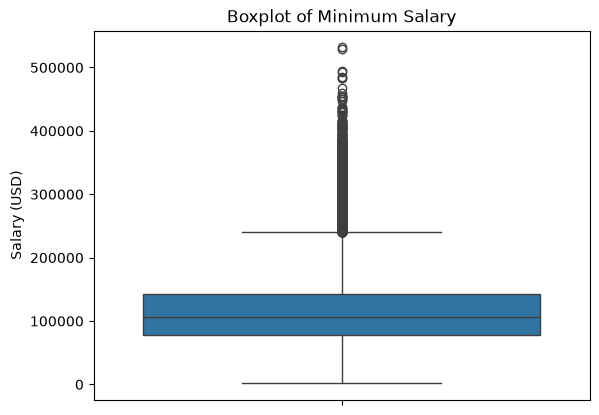

In [268]:
sns.boxplot(y=df['salary_min_usd'])
plt.title('Boxplot of Minimum Salary')
plt.ylabel('Salary (USD)')
plt.show()

The minimum salary data contains several high-value outliers.<br>
Most salaries are concentrated around 70,000–140,000.<br>
A small number of job postings have unusually high minimum salaries, reaching above 500,000.<br>
The middle line represents the median approximately 120000<br>
The dots here represents the outliers<br>
This is right -skewd

In [269]:
percentile25=df['salary_min_usd'].quantile(0.25)
percentile25

np.float64(78300.0)

In [270]:
percentile75=df['salary_min_usd'].quantile(0.75)

In [271]:
iqr=percentile75-percentile25

In [272]:
iqr

np.float64(64900.0)

In [273]:
maximum=percentile75+1.5*iqr
minimum=percentile75-1.5*iqr

In [274]:
maximum


np.float64(240550.0)

In [275]:
minimum

np.float64(45850.0)

### univariate analysis

Univariate numerical-histogram,boxplot,density plot

In [276]:
df['salary_max_usd'].describe()

count    1.150000e+05
mean     1.420839e+05
std      8.926311e+04
min      1.590000e+04
25%      9.420000e+04
50%      1.287000e+05
75%      1.751000e+05
max      3.552000e+06
Name: salary_max_usd, dtype: float64

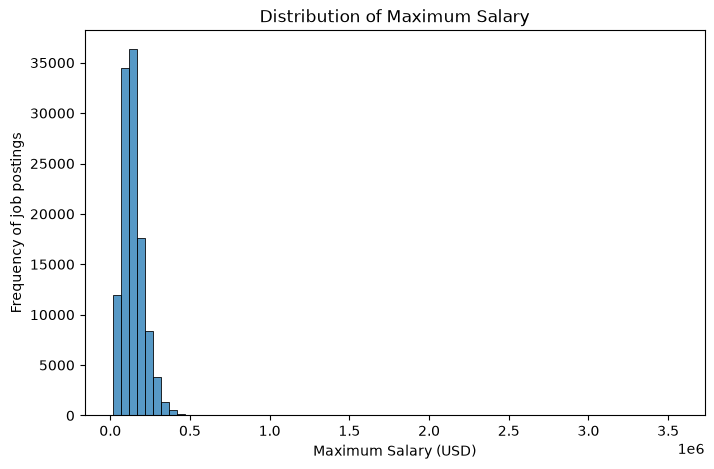

In [277]:
plt.figure(figsize=(8,5))
sns.histplot(df['salary_max_usd'], bins=70)
plt.title('Distribution of Maximum Salary')
plt.xlabel('Maximum Salary (USD)')
plt.ylabel('Frequency of job postings')

plt.show()

Most maximum salaries are concentrated at the lower end between 0.0-0.3.<br>
Therefore the data is right skewed <br>
A few extremely high salary values are likel potentially outliers

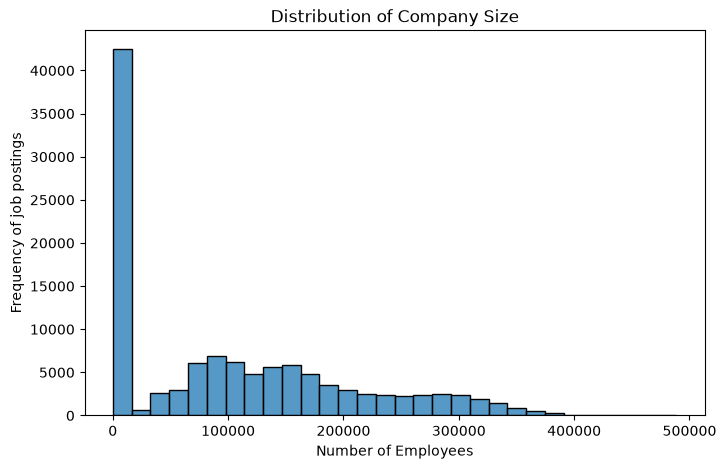

In [278]:
plt.figure(figsize=(8,5))
sns.histplot(df['company_size_employees'], bins=30)
plt.title('Distribution of Company Size')
plt.xlabel('Number of Employees')
plt.ylabel('Frequency of job postings')
plt.show()

Most of the company size values are concentrated near the lower end of the distribution<br>
As the no. of employes increases , frequncy of job postings  generally decreases.<br>
Comapany size distribution is right skewed

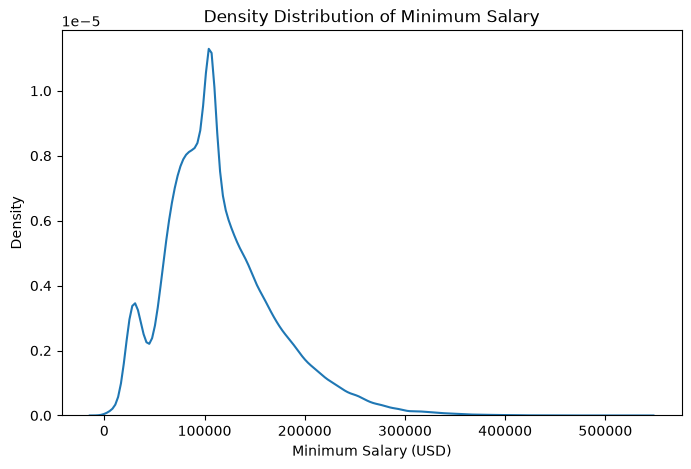

In [279]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df,x='salary_min_usd')
plt.title('Density Distribution of Minimum Salary')
plt.xlabel('Minimum Salary (USD)')
plt.ylabel('Density')

plt.show()

Most minimum salary values are concentrated in the lower salary range.<br>
Only a few jobs have very high minimum salaries,.
The distribution is right skewed .

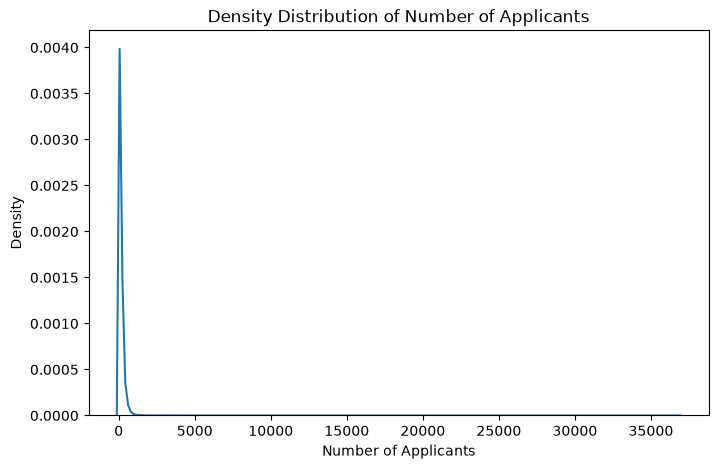

In [280]:
plt.figure(figsize=(8,5))

sns.kdeplot(data=df, x='number_of_applicants')

plt.title('Density Distribution of Number of Applicants')
plt.xlabel('Number of Applicants')
plt.ylabel('Density')

plt.show()

Most job postings have a relatively low number of applicants.<br>
The distribution is highly right-skewed.<br>
A few job postings have an extremely high number of applicants.<br>

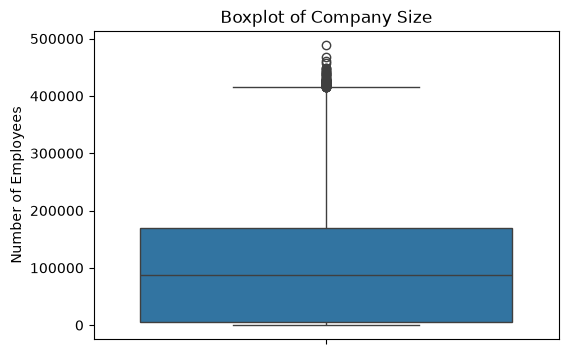

In [281]:
plt.figure(figsize=(6,4))
sns.boxplot(df['company_size_employees'].dropna())
plt.title('Boxplot of Company Size')
plt.ylabel('Number of Employees')
plt.show()

The median company size around 90,000.<br>
The upper whisker is much longer than lower one.<br>
The company size distribution is right-skewed.<br>
There are several high value outliers.


In [282]:
df['company_size_employees'].describe()

count    115000.000000
mean     105386.103122
std      102117.290040
min          10.000000
25%        6038.750000
50%       88364.000000
75%      169840.250000
max      488674.000000
Name: company_size_employees, dtype: float64

Univariate - categorical

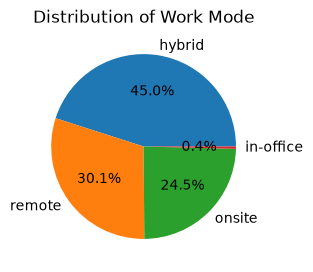

In [283]:
df['work_mode'].value_counts().plot(kind='pie',autopct='%0.1f%%',figsize=(3,3))
plt.title('Distribution of Work Mode')
plt.show()

Hybrid work mode is highly common having 45% job postings.<br>
Remote work is second most common at 30.1%<br>
onsite jobs have 24.5% job postings<br>
in-office work is extremely rare only 0.4% job postings are there

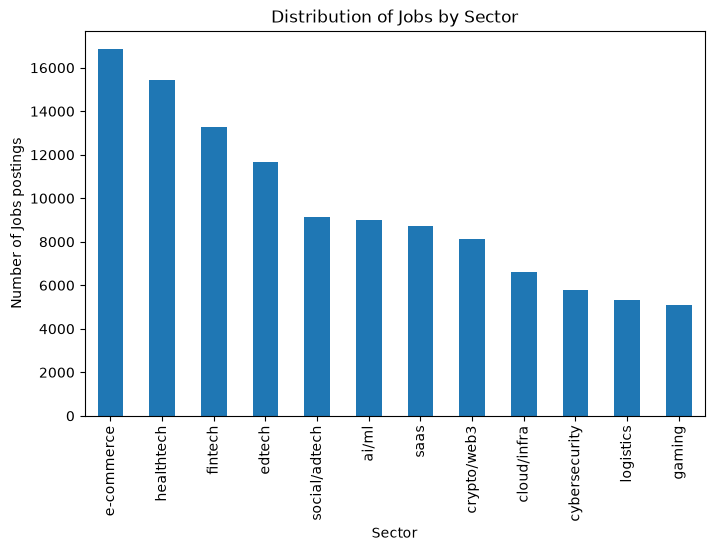

In [284]:
plt.figure(figsize=(8,5))
df['sector'].value_counts().plot(kind='bar')
plt.title('Distribution of Jobs by Sector')
plt.xlabel('Sector')
plt.ylabel('Number of Jobs postings')

plt.show()

E-commerce has the highest number of job postings.<br>
Healthtech has the second-highest number of jobs.<br>
Fintech and Edtech also show a high number of job opportunities.<br>
Gaming has the lowest number of job postings.<br>
overall job opportunities are more concentrated in E-commerce, Healthtech, and Fintech sectors.

### HEATMAP FOR STANDING CORRELATION

<Axes: >

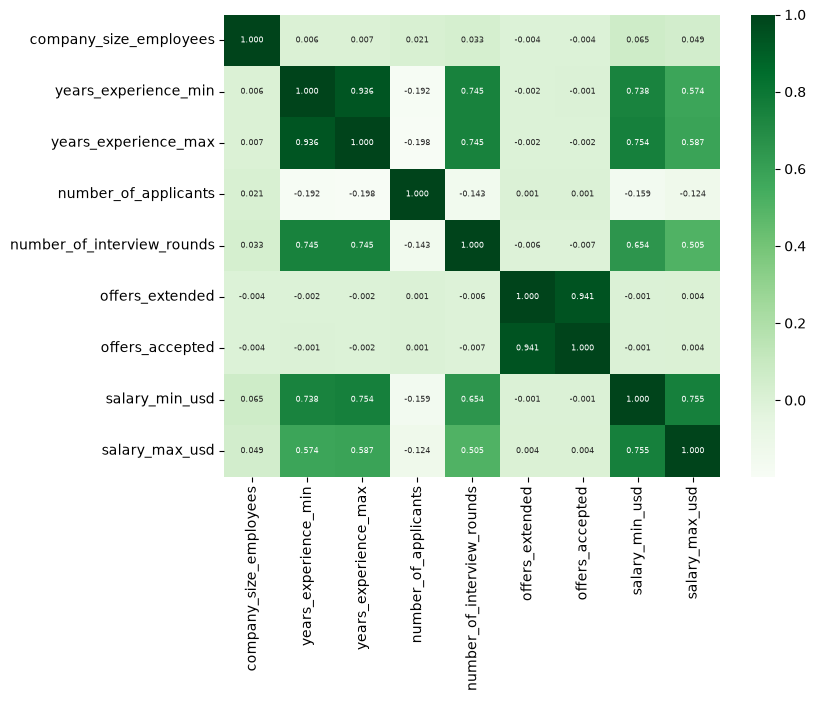

In [285]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only = True) , annot =True , fmt = '.3f' , cmap = 'Greens' , annot_kws = {'size':6})

### By analyzing the heatmap we select the following column for Bivariate analysis
<br>
years_experience_min with salary_min_usd<br>
salary_min_usd with salary_max_usd<br>
offers_extended with offers_accepted <br>
years_experience_max with salary_min_usd<br>
years_experience_min with years_experience_max<br>


### Bivariate analysis

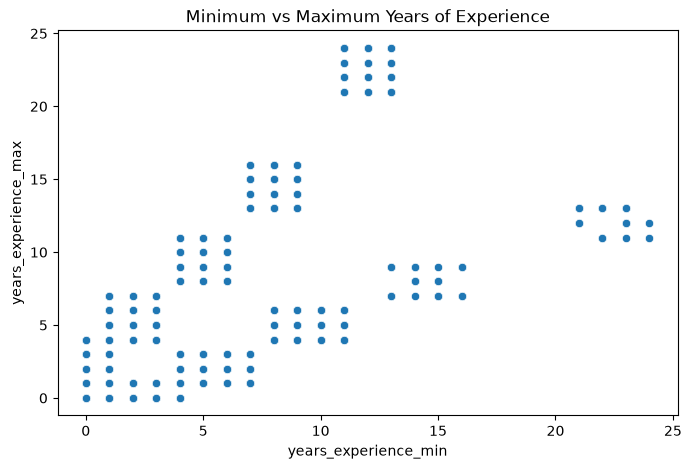

In [286]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='years_experience_min', y='years_experience_max')
plt.title('Minimum vs Maximum Years of Experience')
plt.show()

Each point here represents a job posting.<br>
The plot shows that min and max experience are positively related ..<br>
As min required experience increases ,the max required experience generally also increases.<br> 
The graph shows that different jobs have different experience requirements.


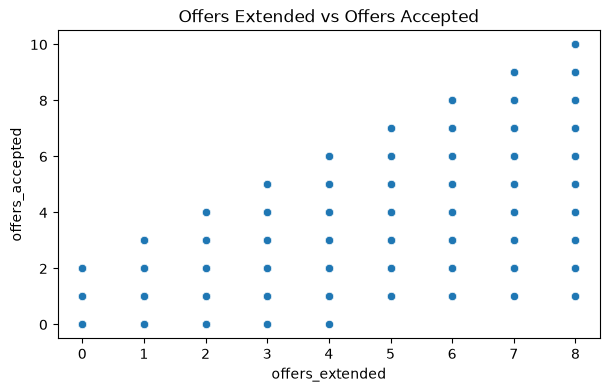

In [287]:
plt.figure(figsize=(7,4))
sns.scatterplot(data=df, x='offers_extended', y='offers_accepted')
plt.title('Offers Extended vs Offers Accepted')
plt.show()

AS number of offer_extended increase we see that number of offer_accepted also increase

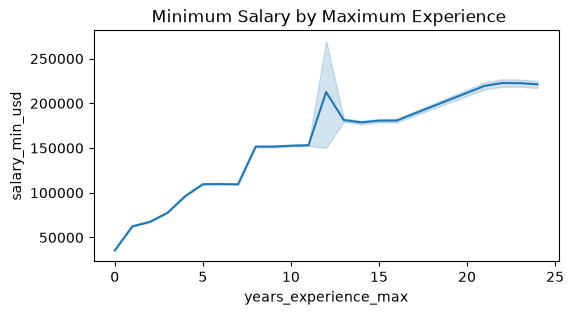

In [288]:
plt.figure(figsize=(6,3))
sns.lineplot(data=df,x='years_experience_max',y='salary_min_usd')
plt.title(' Minimum Salary by Maximum Experience')
plt.show()

Minimum salary generally increases with maximum experience.<br>
Some fluctuations can be seen in the trend.<br>
the line shows that wht we estimate is more precise <br>
This shaded area shows the variation in values or it is less precise

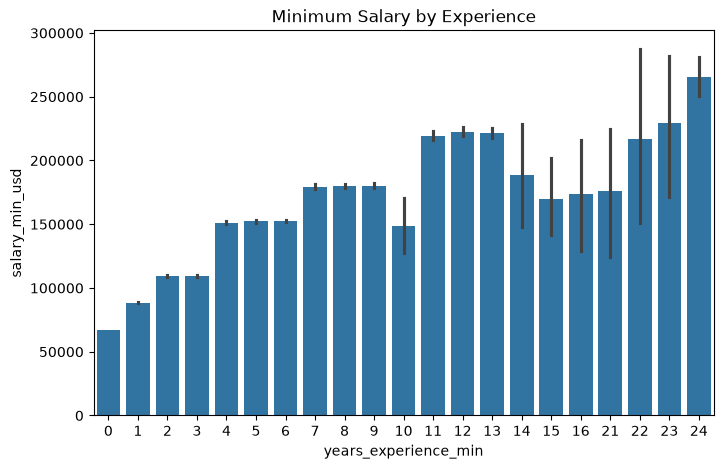

In [289]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x='years_experience_min',y='salary_min_usd')
plt.title('Minimum Salary by Experience')
plt.show()

Minimum salary generally increases with experience.<br>
high experience levels provide high salaries<br>
but there are some exceptions like 10 year has less salary compared to 9 years exp<br>
Here there dark lines represent variations, long dark line represents more variations & the shorter one means less variations

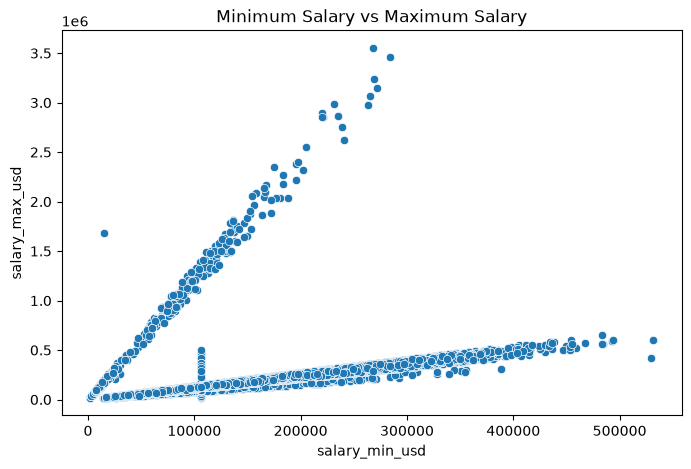

In [290]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x='salary_min_usd',y='salary_max_usd')
plt.title('Minimum Salary vs Maximum Salary')
plt.show()

Generally when min salary increase, max salary also increases.<br>
The point which are far away from main pattern shows that they are outliers.<br>
That V shape pattern here shows that there are different salary patterns in a dataset.<br>
Some jobs have normal salary range, while others have max salary range than others .

### MULTIVARIATE ANALYSIS

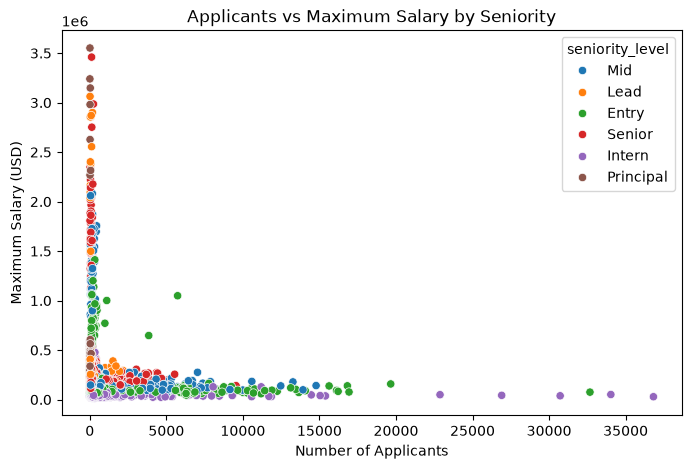

In [291]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x='number_of_applicants',y='salary_max_usd',hue='seniority_level')
plt.title('Applicants vs Maximum Salary by Seniority')
plt.xlabel('Number of Applicants')
plt.ylabel('Maximum Salary (USD)')
plt.show()

Higher max salaries are mostly seen for  jobs withh applicants.<br>
Senior,lead,and principal roles show the highest salary range<br>
Most jobs have lower maximu salaries and a releatively low to moderate number of applicants

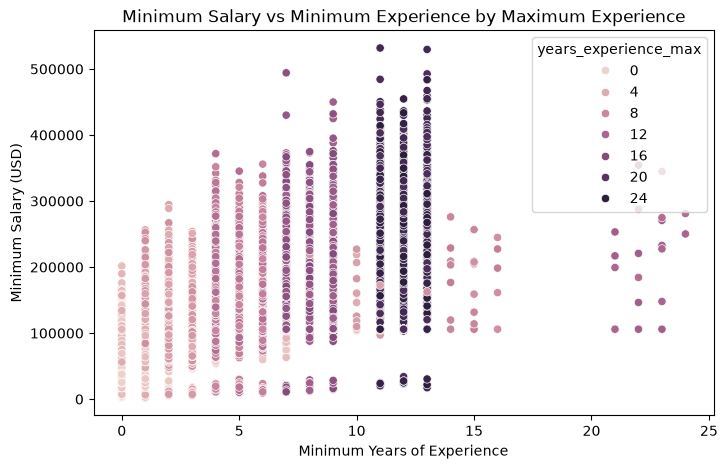

In [292]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x='years_experience_min',y='salary_min_usd',hue='years_experience_max')
plt.title('Minimum Salary vs Minimum Experience by Maximum Experience')
plt.xlabel('Minimum Years of Experience')
plt.ylabel('Minimum Salary (USD)')
plt.show()

Minimum salary generally increases as minimum experience increases.<br>
Higher maximum-experience groups tend to appear at higher salary levels.<br>
Salary variation is higher at medium-to-high experience levels.

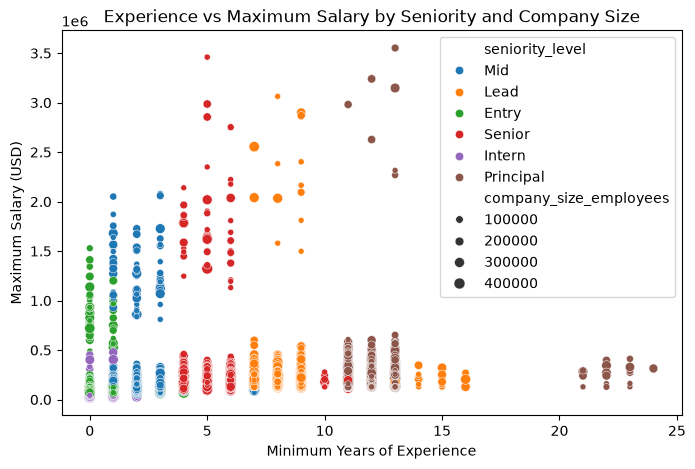

In [293]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x='years_experience_min',y='salary_max_usd',hue='seniority_level',size='company_size_employees')
plt.title('Experience vs Maximum Salary by Seniority and Company Size')
plt.xlabel('Minimum Years of Experience')
plt.ylabel('Maximum Salary (USD)')

plt.show()

Higher seniority levels generally have higher maximum salaries.<br>
Larger companies tend to offer higher salary ranges, shown by larger bubble sizes.<br>
Entry and Mid-level roles are mostly concentrated at lower salary levels, while Senior, Lead and Principal roles show higher salary values.<br>
A few very high salary values appear as outliers.